# GSM8K response matrix and a 2PL IRT fit

This notebook pulls the GSM8K item-level response data, examines the response matrix, filters it to items that can identify IRT parameters, checks that a single dimension is reasonable, and fits a two-parameter IRT model. It then writes out item parameters and model abilities so the next stage can compute residuals.

The data comes from metabench, which assembled item-wise correctness for the six Open LLM Leaderboard v1 benchmarks across more than five thousand models. GSM8K is one of those six.

Before running, download `data.tar.gz` from zenodo.org/records/12819251 and extract it, or run the companion `load_gsm8k_matrix.py` first so the parquet is ready.

Dependencies are numpy, pandas, matplotlib, girth, pyarrow, and pyreadr for the R-format tables. Install them with `pip install numpy pandas matplotlib girth pyarrow pyreadr`.

In [4]:
import os, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Folder holding the extracted metabench data from zenodo.org/records/12819251
DATA_DIR = "./benchmark-data"

# If you already ran load_gsm8k_matrix.py, point this at its output and the
# notebook will load it directly instead of re-reading the raw dump.
MATRIX_PARQUET = "gsm8k_matrix.parquet"

# Pass-rate band that keeps an item identifiable for IRT. Items below LOW sit
# at the floor and items above HIGH sit at the ceiling, so neither carries
# usable difficulty or discrimination information.
LOW, HIGH = 0.05, 0.95

# Set this True only if your loaded table comes in items-by-models orientation.
TRANSPOSE = False

## Step 1. Load the GSM8K matrix

The convention here is that rows are models and columns are items. If your metabench table arrives the other way, set `TRANSPOSE = True` in the cell above.

In [9]:
DATA_DIR = "./benchmark-data"

def find_gsm8k_responses(data_dir):
    files = [p for p in glob.glob(os.path.join(data_dir, "**/*"), recursive=True)
             if os.path.isfile(p)]
    def is_full_responses(p):
        b = os.path.basename(p).lower()
        if not b.startswith("gsm8k"):
            return False
        if "prompt" in b:        # gsm8k_prompts.csv is question text, not responses
            return False
        if "-sub" in b:          # gsm8k-sub-*.rds are the distilled subsets
            return False
        if "split" in b:         # train and test split objects
            return False
        return b.endswith((".csv", ".rds", ".parquet"))
    cands = [p for p in files if is_full_responses(p)]
    # Prefer the raw csv, then the preprocessed full matrix.
    cands.sort(key=lambda p: (
        0 if os.path.basename(p).lower() == "gsm8k.csv" else
        1 if "preproc" in os.path.basename(p).lower() else 2))
    return cands

def load_gsm8k_matrix():
    if os.path.exists(MATRIX_PARQUET):
        print("loading pre-saved", MATRIX_PARQUET)
        return pd.read_parquet(MATRIX_PARQUET)
    cands = find_gsm8k_responses(DATA_DIR)
    if not cands:
        raise FileNotFoundError("No full gsm8k responses file under " + DATA_DIR)
    print("using:", cands[0])

    long = pd.read_csv(cands[0])              # columns: source, item, correct
    print("long format:", long.shape, "columns:", list(long.columns))

    wide = long.pivot_table(index="source", columns="item",
                            values="correct", aggfunc="first")
    wide = wide.astype("float")              # True and False become 1.0 and 0.0
    return wide

raw = load_gsm8k_matrix()
if TRANSPOSE:
    raw = raw.T
print("raw matrix:", raw.shape[0], "models x", raw.shape[1], "items")
raw.iloc[:5, :8]

using: ./benchmark-data/gsm8k.csv
long format: (8839938, 3) columns: ['source', 'item', 'correct']
raw matrix: 6702 models x 1319 items


item,1,2,3,4,5,6,7,8
source,,,,,,,,
0-hero/Matter-0.1-7B-boost-DPO-preview,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
0-hero/Matter-0.1-Slim-7B-C,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
0-hero/Matter-0.1-Slim-7B-C-DPO,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
0-hero/Matter-0.1-Slim-7B-preview,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
0-hero/Matter-0.2-32B,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0


## Step 2. Examine the raw response matrix

The left panel is the pass rate per item across all models, which is where saturation shows up. The right panel is accuracy per model. The dashed lines mark the identifiable band.

models: 6702   items: 1319   missing fraction: 0.0


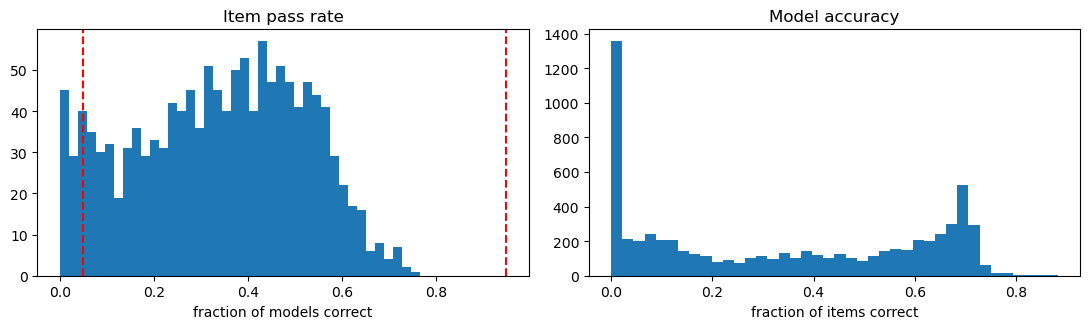

items at or below floor: 105
items at or above ceiling: 0


In [10]:
# Binarize in case values are stored as floats or accuracies rather than 0/1.
M = (raw >= 0.5).astype(float)
M = M.mask(raw.isna())

n_models, n_items = M.shape
missing = float(np.isnan(M.values).mean())
print("models:", n_models, "  items:", n_items, "  missing fraction:", round(missing, 4))

item_pass = M.mean(axis=0, skipna=True)
model_acc = M.mean(axis=1, skipna=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(item_pass.dropna(), bins=40)
ax[0].axvline(LOW, color="r", ls="--")
ax[0].axvline(HIGH, color="r", ls="--")
ax[0].set_title("Item pass rate")
ax[0].set_xlabel("fraction of models correct")
ax[1].hist(model_acc.dropna(), bins=40)
ax[1].set_title("Model accuracy")
ax[1].set_xlabel("fraction of items correct")
plt.tight_layout()
plt.show()

print("items at or below floor:", int((item_pass <= LOW).sum()))
print("items at or above ceiling:", int((item_pass >= HIGH).sum()))

## Step 3. Filter to identifiable items and models

Keep items inside the informative band and drop models that answer everything right or everything wrong, since a degenerate response vector contributes nothing to estimation.

In [11]:
keep_items = item_pass.between(LOW, HIGH)
Mf = M.loc[:, keep_items]

keep_models = Mf.mean(axis=1, skipna=True).between(0.001, 0.999)
Mf = Mf.loc[keep_models]

Mf = Mf.dropna(how="all").dropna(axis=1, how="all")
print("after filter:", Mf.shape[0], "models x", Mf.shape[1], "items")
print("retained", round(100 * Mf.shape[1] / n_items, 1), "percent of items")

after filter: 6014 models x 1214 items
retained 92.0 percent of items


## Step 4. Unidimensionality sanity check

A single dominant eigenvalue on the item correlation matrix supports a one-factor structure, which is the property the whole study is organized around. This uses Pearson correlations on binary data as a fast stand-in for the tetrachoric version, so read it as a sanity check rather than a final test.

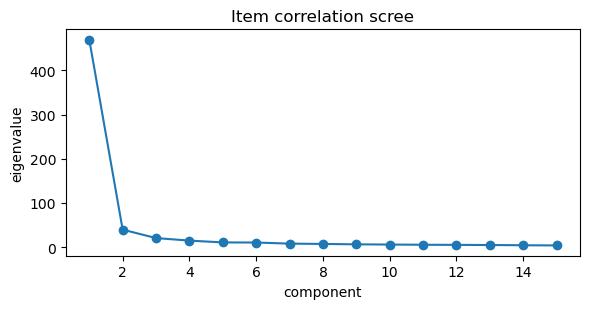

first eigenvalue: 469.89  second: 39.55  ratio: 11.88


In [12]:
Xi = Mf.fillna(Mf.mean())
C = np.corrcoef(Xi.values, rowvar=False)
eig = np.sort(np.linalg.eigvalsh(C))[::-1]

plt.figure(figsize=(6, 3.2))
plt.plot(range(1, 16), eig[:15], "o-")
plt.title("Item correlation scree")
plt.xlabel("component")
plt.ylabel("eigenvalue")
plt.tight_layout()
plt.show()

print("first eigenvalue:", round(float(eig[0]), 2),
      " second:", round(float(eig[1]), 2),
      " ratio:", round(float(eig[0] / eig[1]), 2))

## Step 5. Fit the 2PL

girth fits a two-parameter model by marginal maximum likelihood and expects an array shaped items by models, so we transpose. girth runs its EM internally and does not stream progress, so the cell reports the work size up front and the elapsed time at the end.

In [17]:
# 1. Write the filtered matrix to the jsonlines format py-irt reads.
import json

JSONL = "gsm8k_responses.jsonlines"
with open(JSONL, "w") as f:
    for model, row in Mf.iterrows():
        responses = {str(it): int(v) for it, v in row.dropna().items()}
        f.write(json.dumps({"subject_id": str(model), "responses": responses}) + "\n")
print("wrote", JSONL, "for", Mf.shape[0], "models and", Mf.shape[1], "items")

wrote gsm8k_responses.jsonlines for 6014 models and 1214 items


In [20]:
import os, json, glob, subprocess
OUT = "irt_out"
LOG = "irt_train.log"

# Allow the duplicate OpenMP runtime, and send the trainer's per-epoch output
# to a log file instead of the notebook.
env = dict(os.environ, KMP_DUPLICATE_LIB_OK="TRUE")
with open(LOG, "w") as log:
    rc = subprocess.run(
        ["py-irt", "train", "2pl", JSONL, OUT],
        env=env, stdout=log, stderr=subprocess.STDOUT,
    ).returncode

print("exit code:", rc)
print("last lines of", LOG)
print("\n".join(open(LOG).read().splitlines()[-12:]))

# Load whatever parameter file the trainer wrote.
path = os.path.join(OUT, "best_parameters.json")
if not os.path.exists(path):
    hits = glob.glob(os.path.join(OUT, "*.json"))
    path = hits[0] if hits else None
print("\nparam file:", path)
if path:
    P = json.load(open(path))
    print("keys:", list(P.keys()))

exit code: 0
last lines of irt_train.log
│ 1101  │ 2750903.3123  │ 2750414.7524  │ 0.0896 │
│ 1201  │ 2749373.6938  │ 2747569.5513  │ 0.0887 │
│ 1301  │ 2745977.4995  │ 2744976.5740  │ 0.0878 │
│ 1401  │ 2743785.2350  │ 2742964.8667  │ 0.0869 │
│ 1501  │ 2743022.5632  │ 2741441.5709  │ 0.0861 │
│ 1601  │ 2741693.1598  │ 2740432.5149  │ 0.0852 │
│ 1701  │ 2739559.5258  │ 2739310.3030  │ 0.0844 │
│ 1801  │ 2738962.7664  │ 2738659.4541  │ 0.0835 │
│ 1901  │ 2738307.7280  │ 2737713.7394  │ 0.0827 │
│ 2000  │ 2737934.9406  │ 2737454.5265  │ 0.0819 │
└───────┴───────────────┴───────────────┴────────┘
[11:08:11] Train time: 183.317147731781                               ]8;id=113390;file:///Users/christopherstewart/miniconda3/lib/python3.10/site-packages/py_irt/cli.py\cli.py]8;;\:]8;id=39118;file:///Users/christopherstewart/miniconda3/lib/python3.10/site-packages/py_irt/cli.py#122\122]8;;\

param file: irt_out/best_parameters.json
keys: ['ability', 'diff', 'disc', 'irt_model', 'item_i

In [29]:
diff = np.asarray(pick(P, "diff", "difficulty"), dtype=float)
disc = np.asarray(pick(P, "disc", "discrimination"), dtype=float)
abil = np.asarray(pick(P, "ability", "theta"), dtype=float)

params = pd.DataFrame({
    "item": ordered_ids(pick(P, "item_ids"), len(diff)),
    "difficulty": diff,
    "discrimination": disc,
})
abilities = pd.DataFrame({
    "model": ordered_ids(pick(P, "subject_ids"), len(abil)),
    "ability": abil,
})

print("n items:", len(params))
print("labels match matrix columns:",
      set(params["item"].astype(int)) == set(int(c) for c in Mf.columns))
params.head()

n items: 1214
labels match matrix columns: True


,item,difficulty,discrimination
0,1,1.036702,0.996061
1,2,-0.803863,1.828109
2,3,0.571784,1.713954
3,4,0.283789,1.644372
4,5,0.437891,2.600274


## Step 6. Examine the item parameters

Difficulty should spread across a usable range and discrimination should mostly sit well above zero. A cluster near zero discrimination flags items that fail to separate models and would be candidates to drop.

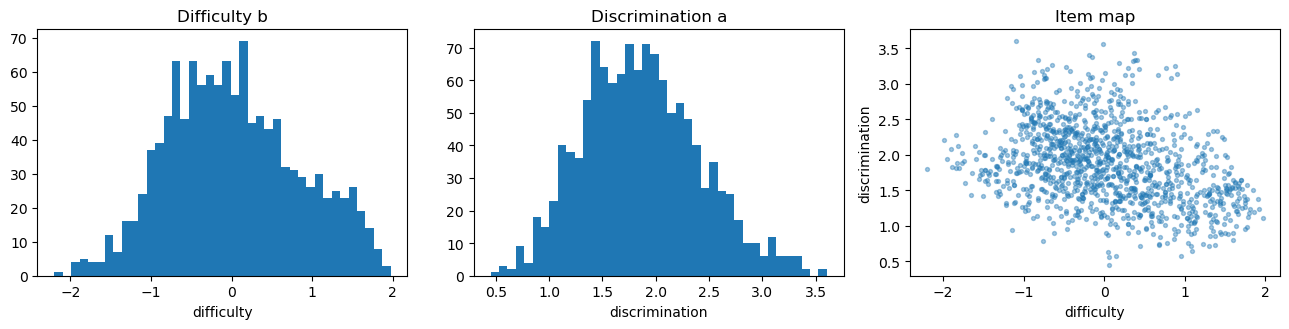

items: 1214
median discrimination: 1.83
items with discrimination below 0.3: 0
difficulty range: -2.2 to 1.97

most discriminating items:
item  difficulty  discrimination
1153   -1.093136        3.605856
 138   -0.011581        3.550773
 545    0.370646        3.432332
 148   -0.189336        3.400192
 997   -0.150203        3.368828
  31    0.386905        3.337832
1288    0.404657        3.328858
 975   -0.825502        3.327223


In [31]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(params["difficulty"], bins=40)
ax[0].set_title("Difficulty b")
ax[0].set_xlabel("difficulty")
ax[1].hist(params["discrimination"], bins=40)
ax[1].set_title("Discrimination a")
ax[1].set_xlabel("discrimination")
ax[2].scatter(params["difficulty"], params["discrimination"], s=8, alpha=0.4)
ax[2].set_xlabel("difficulty")
ax[2].set_ylabel("discrimination")
ax[2].set_title("Item map")
plt.tight_layout()
plt.show()

print("items:", len(params))
print("median discrimination:", round(float(params["discrimination"].median()), 2))
print("items with discrimination below 0.3:", int((params["discrimination"] < 0.3).sum()))
print("difficulty range:", round(float(params["difficulty"].min()), 2),
      "to", round(float(params["difficulty"].max()), 2))
print("\nmost discriminating items:")
print(params.sort_values("discrimination", ascending=False).head(8).to_string(index=False))

## Step 7. Estimate abilities and save

Expected a posteriori scoring gives each model a latent ability on the same scale as the item difficulties. The three saved files are what the residual screen consumes next.

In [32]:
params.to_csv("gsm8k_2pl_item_params.csv", index=False)
abilities.to_csv("gsm8k_2pl_abilities.csv", index=False)
Mf.to_parquet("gsm8k_matrix_filtered.parquet")

print("wrote:")
print("  gsm8k_2pl_item_params.csv    ", params.shape)
print("  gsm8k_2pl_abilities.csv      ", abilities.shape)
print("  gsm8k_matrix_filtered.parquet", Mf.shape)
abilities.sort_values("ability", ascending=False).head()

wrote:
  gsm8k_2pl_item_params.csv     (1214, 3)
  gsm8k_2pl_abilities.csv       (6014, 2)
  gsm8k_matrix_filtered.parquet (6014, 1214)


,model,ability
1503,MaziyarPanahi/Llama-3-70B-Instruct-DPO-v0.2,1.813239
1505,MaziyarPanahi/Llama-3-70B-Instruct-DPO-v0.4,1.792252
4882,mmnga/Llama-3-70B-japanese-suzume-vector-v0.1,1.781613
1504,MaziyarPanahi/Llama-3-70B-Instruct-DPO-v0.3,1.675052
1502,MaziyarPanahi/Llama-3-70B-Instruct-DPO-v0.1,1.612617


## Step 8. Residual Screen

Here we compute each model-item 2PL residual, then flag the large positive residuals on hard items as preknowledge suspects for the perturbation stage.

In [34]:
# Align parameters to the matrix and build predicted probabilities.
import numpy as np, pandas as pd
from scipy.special import expit

# Item params to columns, abilities to rows. Mf columns are integer item ids.
cols = [int(c) for c in Mf.columns]
a = pd.Series(params["discrimination"].values, index=params["item"].astype(int)).reindex(cols).values
b = pd.Series(params["difficulty"].values, index=params["item"].astype(int)).reindex(cols).values
theta = pd.Series(abilities["ability"].values, index=abilities["model"].astype(str)).reindex(Mf.index.astype(str)).values

assert not np.isnan(a).any() and not np.isnan(b).any(), "unmatched items"
assert not np.isnan(theta).any(), "unmatched models"

U = Mf.values.astype(float)                 # observed 0/1, may contain NaN
obs_item = np.nanmean(U, axis=0)

# Auto-detect the difficulty sign by picking the convention that calibrates.
def pred(sign):
    return expit(a[None, :] * (theta[:, None] - sign * b[None, :]))
corr_minus = np.corrcoef(obs_item, np.nanmean(pred(+1.0), axis=0))[0, 1]   # theta - b
corr_plus  = np.corrcoef(obs_item, np.nanmean(pred(-1.0), axis=0))[0, 1]   # theta + b
sign = 1.0 if corr_minus >= corr_plus else -1.0
P = np.clip(pred(sign), 1e-6, 1 - 1e-6)

print("convention: P = sigmoid(a * (theta", "-" if sign > 0 else "+", "b))")
print("item calibration corr:", round(float(max(corr_minus, corr_plus)), 3))
print("mean observed:", round(float(np.nanmean(U)), 3),
      " mean predicted:", round(float(np.nanmean(P)), 3))

convention: P = sigmoid(a * (theta - b))
item calibration corr: 0.999
mean observed: 0.405  mean predicted: 0.405


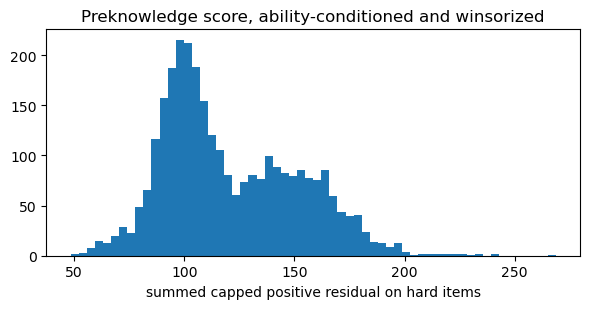

models with a nonzero score: 3007
                                              model  preknowledge_score  hard_cells_capped  mean_ability  plausible
                    Weyaxi/Einstein-v4-Qwen-1.5-32B          268.624808                  2      0.096481       True
                       nvidia/Llama3-ChatQA-1.5-70B          241.635781                  0      0.520586       True
                         logicker/SkkuDS-DPO-72B-v3          240.855165                  0      0.496912       True
                         logicker/SkkuDS-DPO-72B-v1          233.710848                  0      0.572049       True
                    CohereForAI/c4ai-command-r-plus          233.526726                  6     -0.072344       True
                                   Qwen/Qwen1.5-72B          228.843437                  0      0.569534       True
                       4season/alignment_model_test          227.088322                  0      0.259970       True
                  deepseek-ai/deepseek

In [37]:
# One-sided screen with winsorized residuals, conditioned on ability.
Z = (U - P) / np.sqrt(P * (1 - P))

Z_CAP = 4.0                       # no single cell counts more than this
HARD_Q = 0.75                     # hard means top quartile of difficulty
b_eff = sign * b
hard = b_eff > np.nanquantile(b_eff, HARD_Q)

# Only models at or above median ability can plausibly show preknowledge
# rather than a small-denominator artifact.
plausible = theta >= np.nanmedian(theta)

Zc = np.clip(Z, -Z_CAP, Z_CAP)
Zpos = np.where((Zc > 0) & ~np.isnan(Zc), Zc, 0.0)

score = Zpos[:, hard].sum(axis=1)
score = np.where(plausible, score, 0.0)          # zero out implausible models
n_hard_flags = ((Zc >= Z_CAP) & hard[None, :] & ~np.isnan(Zc)).sum(axis=1)

screen = pd.DataFrame({
    "model": Mf.index,
    "preknowledge_score": score,
    "hard_cells_capped": n_hard_flags,
    "mean_ability": theta,
    "plausible": plausible,
}).sort_values("preknowledge_score", ascending=False).reset_index(drop=True)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3.2))
plt.hist(score[score > 0], bins=60)
plt.title("Preknowledge score, ability-conditioned and winsorized")
plt.xlabel("summed capped positive residual on hard items")
plt.tight_layout()
plt.show()

print("models with a nonzero score:", int((score > 0).sum()))
print(screen.head(20).to_string(index=False))

In [38]:
# Cell-level candidates, capped residual and quartile-hard.
Z_FLAG = 4.0
mask = (Zc >= Z_FLAG) & hard[None, :] & plausible[:, None] & ~np.isnan(Zc)
ri, ci = np.where(mask)
flags = pd.DataFrame({
    "model": Mf.index.values[ri],
    "item": np.array(cols)[ci],
    "z_capped": Zc[ri, ci],
    "z_raw": Z[ri, ci],
    "difficulty": b_eff[ci],
    "predicted_p": P[ri, ci],
}).sort_values("z_raw", ascending=False).reset_index(drop=True)

print("flagged cells:", len(flags), "across", flags["model"].nunique(), "models")
print(flags.head(15).to_string(index=False))

screen.to_csv("gsm8k_preknowledge_screen.csv", index=False)
flags.to_csv("gsm8k_flagged_cells.csv", index=False)
print("\nwrote gsm8k_preknowledge_screen.csv and gsm8k_flagged_cells.csv")

flagged cells: 848 across 424 models
                                       model  item  z_capped    z_raw  difficulty  predicted_p
                    JaeyeonKang/CCK-v2.0-DPO    81       4.0 7.030027    1.464478     0.019833
  HenryJJ/dolphin-2.6-mistral-7b-dpo-orca-v2    81       4.0 6.871785    1.464478     0.020738
                   NeuralNovel/Gecko-7B-v0.1   842       4.0 6.699568    1.398615     0.021794
OpenBuddy/openbuddy-falcon-180b-v12-preview0   314       4.0 6.666153    1.354631     0.022008
                   kyujinpy/PlatYi-34B-Llama  1023       4.0 6.649731    1.488788     0.022115
                       elinas/chronos007-70b   842       4.0 6.642461    1.398615     0.022162
   uukuguy/speechless-mistral-hermes-code-7b   314       4.0 6.490818    1.354631     0.023185
       OpenBuddy/openbuddy-llama-65b-v8-bf16  1023       4.0 6.469562    1.488788     0.023334
       OpenBuddy/openbuddy-llama-65b-v8-bf16    81       4.0 6.438162    1.464478     0.023557
             

In [39]:
# Which items get flagged across many models. These are the strongest
# item-level contamination candidates for the perturbation stage.
item_hits = (flags.groupby("item")
                  .agg(n_models=("model", "nunique"),
                       median_pred_p=("predicted_p", "median"),
                       median_difficulty=("difficulty", "median"))
                  .sort_values("n_models", ascending=False))
print(item_hits.head(20).to_string())
print("\nitems flagged by 3 or more models:", int((item_hits["n_models"] >= 3).sum()))

      n_models  median_pred_p  median_difficulty
item                                            
365         37       0.043502           1.569880
842         34       0.046831           1.398615
382         34       0.049361           1.677728
260         33       0.051720           1.622215
214         30       0.045509           1.773895
948         29       0.039095           1.530383
1074        28       0.048625           1.848652
368         26       0.051849           1.664911
1023        26       0.043250           1.488788
1043        24       0.047897           1.694935
484         23       0.051425           1.486031
638         22       0.051473           1.546406
81          22       0.045238           1.464478
314         22       0.032672           1.354631
143         22       0.039503           0.763149
1016        21       0.051811           1.697494
787         21       0.051780           1.596537
703         20       0.051816           1.705658
1228        19      

## Step 9. Map candidate items to their prompts

Here we attach the GSM8K question and answer text to the recurring flagged items and confirm how the metabench item numbers line up with the canonical GSM8K test split. This mapping is what lets the perturbation stage pull the matching GSM-Plus variant for each suspect item, so the same-item flip test compares like with like.

In [40]:
# Load GSM8K prompts and identify the id, question, and answer columns.
import pandas as pd, numpy as np

prompts = pd.read_csv("./benchmark-data/gsm8k_prompts.csv")
print("raw columns:", list(prompts.columns), " rows:", len(prompts))

cols = prompts.columns.tolist()
obj = [c for c in cols if prompts[c].dtype == object]
our_items = set(int(i) for i in item_hits.index)

# id column is the numeric column whose values overlap our item labels.
id_col = None
for c in cols:
    s = pd.to_numeric(prompts[c], errors="coerce")
    if s.notna().mean() > 0.9 and len(set(s.dropna().astype(int)) & our_items) > 0:
        id_col = c
        break
if id_col is None:
    prompts = prompts.reset_index().rename(columns={"index": "item"})
    id_col = "item"
    print("no id column matched, using row order as item, verify the offset below")

# question is the longest text column, answer is the column carrying the GSM8K #### marker.
qcol = max(obj, key=lambda c: prompts[c].astype(str).str.len().median()) if obj else None
acol = next((c for c in obj if prompts[c].astype(str).str.contains("####").mean() > 0.5), None)

print("detected -> id:", id_col, " question:", qcol, " answer:", acol)
prompts[[id_col] + [c for c in [qcol, acol] if c]].head(3)

raw columns: ['item', 'prompt']  rows: 1319
detected -> id: item  question: prompt  answer: prompt


,item,prompt,prompt
0,1,Question: Mr. Bodhi is transporting some anima...,Question: Mr. Bodhi is transporting some anima...
1,2,Question: The owner of a company needs to inst...,Question: The owner of a company needs to inst...
2,3,Question: Two runners are competing in a 10-mi...,Question: Two runners are competing in a 10-mi...


In [41]:
# Attach prompts to the recurring candidate items.
top = item_hits[item_hits["n_models"] >= 3].copy()
pp = prompts.rename(columns={id_col: "item"})
pp["item"] = pd.to_numeric(pp["item"], errors="coerce").astype("Int64")

cand = top.reset_index().merge(pp, on="item", how="left")
have = cand[qcol].notna().sum() if qcol else 0
print("candidate items:", len(cand), " with prompt text:", int(have))

row = cand.sort_values("n_models", ascending=False).iloc[0]
print("\nstrongest candidate is item", int(row["item"]),
      "flagged by", int(row["n_models"]), "models")
print(str(row[qcol])[:600] if qcol else "no question column")
cand.to_csv("gsm8k_candidate_items.csv", index=False)

candidate items: 57  with prompt text: 57

strongest candidate is item 365 flagged by 37 models
Question: Olaf has an aquarium. He has fish in 3 different colors: orange, green, and blue. Blue fish make up half of all the fish in the aquarium. There are 15 fewer orange fish than blue fish. How many green fish are there when the total number of fish in the aquarium is 80?
Answer: If there are 80 fish in total, then there are 80 fish / 2 = <<80/2=40>>40 blue fish.
The orange fish count is 15 less than blue, so it's 40 fish - 15 fish = 25 fish.
Olaf has then 80 fish - 25 fish - 40 fish = <<80-25-40=15>>15 green fish.
#### 15

Question: There are 14 caterpillars on the tree. 4 more eggs hatc


In [42]:
# Confirm metabench item numbers map to the GSM8K test split.

# GSM8K test has 1,319 rows. metabench labels look 1-based, so test whether
# label N maps to canonical row N-1 or to row N.
try:
    from datasets import load_dataset
    gsm = load_dataset("gsm8k", "main", split="test")
    canon = list(gsm["question"])
    print("canonical GSM8K test rows:", len(canon))

    def normf(s):
        return " ".join(str(s).split()).lower()

    sample = cand.dropna(subset=[qcol]).drop_duplicates("item").head(30)
    for off, label in [(1, "N-1, 1-based"), (0, "N, 0-based")]:
        hits, checked = 0, 0
        for _, r in sample.iterrows():
            idx = int(r["item"]) - off
            if 0 <= idx < len(canon):
                checked += 1
                key = normf(canon[idx])[:80]
                if key and key in normf(r[qcol]):
                    hits += 1
        print(f"offset {label}: {hits}/{checked} prompts match the canonical question")
except Exception as e:
    print("could not load canonical GSM8K:", e)
    print("pip install datasets, then rerun, or compare a few prompts by hand")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

canonical GSM8K test rows: 1319
offset N-1, 1-based: 0/30 prompts match the canonical question
offset N, 0-based: 0/30 prompts match the canonical question


In [58]:
# Match the extracted 5-shot targets to GSM8K and attach gold answers.
import re, difflib
from datasets import load_dataset

gsm = load_dataset("gsm8k", "main")
pool_q, pool_a = [], []
for split in ["test", "train"]:
    pool_q += list(gsm[split]["question"])
    pool_a += list(gsm[split]["answer"])
pool_norm = [norm(q) for q in pool_q]
pool_toks = [set(n.split()) for n in pool_norm]
print("gsm pool size:", len(pool_q))

def match_target(target):
    q = norm(target)
    qt = set(q.split())
    top = sorted(range(len(pool_q)),
                 key=lambda i: len(qt & pool_toks[i]) / (len(qt | pool_toks[i]) or 1),
                 reverse=True)[:5]
    bi, br = None, 0.0
    for i in top:
        r = difflib.SequenceMatcher(None, q, pool_norm[i]).ratio()
        if r > br:
            br, bi = r, i
    return (bi, round(br, 3)) if br >= 0.9 else (None, round(br, 3))

s = allp.set_index("item")[qcol]
rows = []
for it in [int(i) for i in item_hits.index]:
    tgt = extract_target(s.loc[it])
    bi, br = match_target(tgt)
    rows.append({"item": it, "match_ratio": br,
                 "gold_answer": pool_a[bi] if bi is not None else None,
                 "target": tgt})

cand_gold = pd.DataFrame(rows)
print("matched", cand_gold["gold_answer"].notna().sum(), "of", len(cand_gold), "flagged items")
print(cand_gold.sort_values("match_ratio").head()[["item", "match_ratio"]].to_string(index=False))
cand_gold.to_csv("gsm8k_flagged_with_gold.csv", index=False)

gsm pool size: 8792
matched 63 of 63 flagged items
 item  match_ratio
  365          1.0
  381          1.0
  288          1.0
  588          1.0
  782          1.0


## Next steps: from screen to confirmation

The screen produced 63 recurring flagged items and the suspect models per item. Confirming contamination means perturbation, but that rests on being able to re-run these open models and reproduce their recorded scores, which we have not yet checked. So the work would proceed in stages, starting with the cheapest and easiest to ensure feasibility.

1. Reproduce the original responses: Take three small flagged models and ten flagged items, run the originals through a local harness in the same 5-shot format, and compare to the stored matrix entries. If scores can not be reproduced, the gap is harness or answer parsing, and that would need to be fixed before anything else.

2. Build numeric twins: For each flagged item, read the arithmetic from its gold worked solution, resample the input numbers, replay the same operations for a new answer, and rewrite the question. After swapping in new numbers, keep a twin only if replaying the arithmetic yields a clean answer, usually a positive integer, and resample the rest.

3. Run one item end to end: Take a single recurring item, run its 20 to 30 suspect models on the original and the twin, and read the flip rate. Memorization shows as passing the original and failing the twin. Genuine skill passes both.

4. Widen the frame: If the single item shows the effect, extend to the rest, capping model size on the first pass since most flagged models are 7B or smaller. An item where many suspects flip is a hypothetical leak.

One reminder. The screen is correlational and only narrows the search. Perturbation is what licenses any claim of contamination, so no flagged item is a finding until its twins are run.